In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="HouseValue")

print(X.head())
print(y.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HouseValue, dtype: float64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (16512, 8)
Testing samples: (4128, 8)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

In [12]:
lr_mae = mean_absolute_error(y_test, y_pred)
lr_mse = mean_squared_error(y_test, y_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance Metrics\n")

print(f"MAE  : {lr_mae:.4f}")
print(f"MSE  : {lr_mse:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression Performance Metrics

MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758


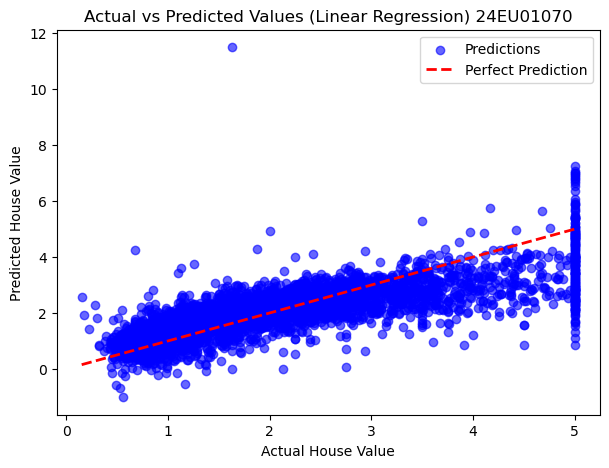

In [14]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred,
            color="blue",
            alpha=0.6,
            label="Predictions")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Values (Linear Regression) 24EU01070")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.legend()

plt.show()

In [16]:
svr_model = SVR(kernel='rbf')

svr_model.fit(X_train_scaled, y_train)

svr_predictions = svr_model.predict(X_test_scaled)

In [17]:
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)

print("Support Vector Regression Performance Metrics\n")

print(f"MAE  : {svr_mae:.4f}")
print(f"MSE  : {svr_mse:.4f}")
print(f"RMSE : {svr_rmse:.4f}")
print(f"R²   : {svr_r2:.4f}")

Support Vector Regression Performance Metrics

MAE  : 0.3986
MSE  : 0.3570
RMSE : 0.5975
R²   : 0.7276


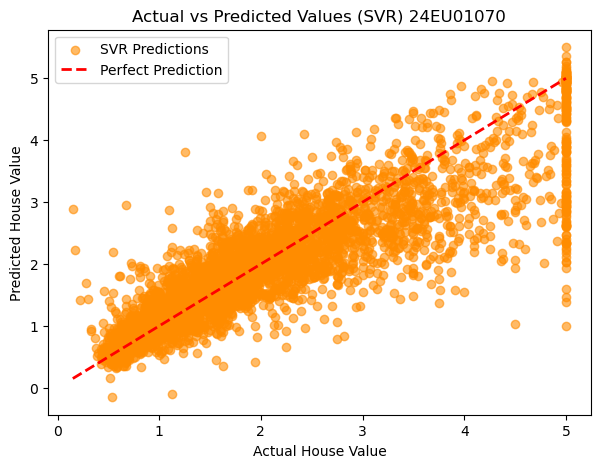

In [20]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    svr_predictions,
    color='darkorange',
    alpha=0.6,
    label='SVR Predictions'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Prediction'
)

plt.title("Actual vs Predicted Values (SVR) 24EU01070")

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")

plt.legend()

plt.show()

In [22]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [24]:
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Regression Performance Metrics\n")

print(f"MAE  : {dt_mae:.4f}")
print(f"MSE  : {dt_mse:.4f}")
print(f"RMSE : {dt_rmse:.4f}")
print(f"R²   : {dt_r2:.4f}")

Decision Tree Regression Performance Metrics

MAE  : 0.4547
MSE  : 0.4952
RMSE : 0.7037
R²   : 0.6221


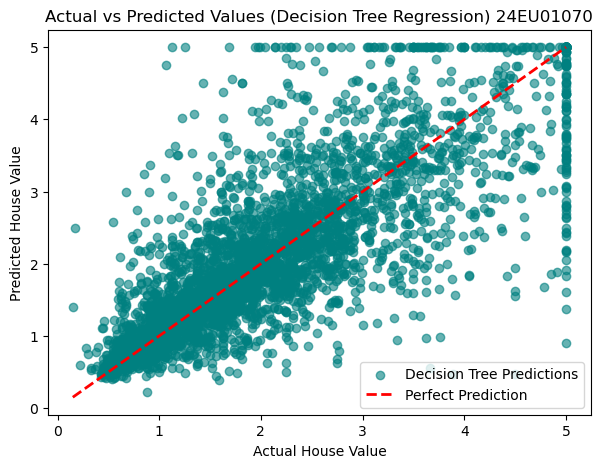

In [28]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    dt_predictions,
    color='teal',
    alpha=0.6,
    label='Decision Tree Predictions'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Prediction'
)

plt.title("Actual vs Predicted Values (Decision Tree Regression) 24EU01070")

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")

plt.legend()

plt.show()

In [30]:
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Regression Performance Metrics\n")

print(f"MAE  : {dt_mae:.4f}")
print(f"MSE  : {dt_mse:.4f}")
print(f"RMSE : {dt_rmse:.4f}")
print(f"R²   : {dt_r2:.4f}")

Decision Tree Regression Performance Metrics

MAE  : 0.4547
MSE  : 0.4952
RMSE : 0.7037
R²   : 0.6221


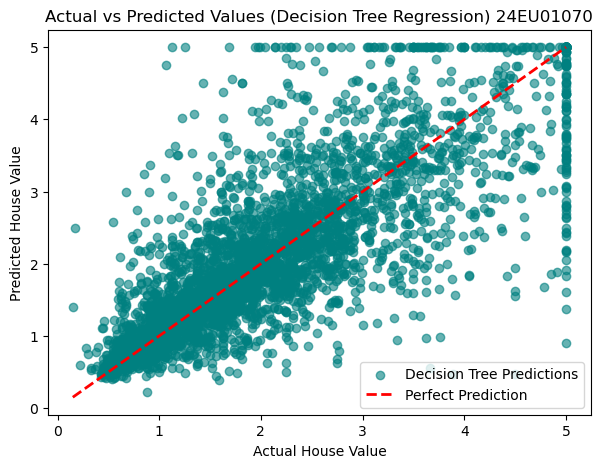

In [34]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    dt_predictions,
    color='teal',
    alpha=0.6,
    label='Decision Tree Predictions'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Prediction'
)

plt.title("Actual vs Predicted Values (Decision Tree Regression) 24EU01070")

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")

plt.legend()

plt.show()

In [36]:
performance = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Support Vector Regression",
        "Decision Tree Regression"
    ],

    "MAE": [
        lr_mae,
        svr_mae,
        dt_mae
    ],

    "MSE": [
        lr_mse,
        svr_mse,
        dt_mse
    ],

    "RMSE": [
        lr_rmse,
        svr_rmse,
        dt_rmse
    ],

    "R² Score": [
        lr_r2,
        svr_r2,
        dt_r2
    ]
})

print("Regression Model Performance Comparison")

performance

Regression Model Performance Comparison


,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,0.533200,0.555892,0.745581,0.575788
1,Support Vector Regression,0.398599,0.357004,0.597498,0.727563
2,Decision Tree Regression,0.454679,0.495235,0.703729,0.622076


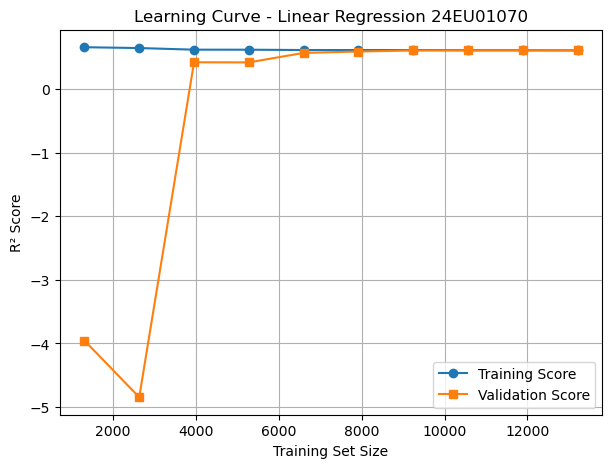

In [38]:
lr_model = LinearRegression()

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=lr_model,
    X=X_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1,1.0,10),
    cv=5,
    scoring='r2'
)

train_mean = np.mean(train_scores, axis=1)
validation_mean = np.mean(validation_scores, axis=1)

plt.figure(figsize=(7,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Score'
)

plt.plot(
    train_sizes,
    validation_mean,
    marker='s',
    label='Validation Score'
)

plt.title("Learning Curve - Linear Regression 24EU01070")

plt.xlabel("Training Set Size")
plt.ylabel("R² Score")

plt.grid(True)
plt.legend()

plt.show()

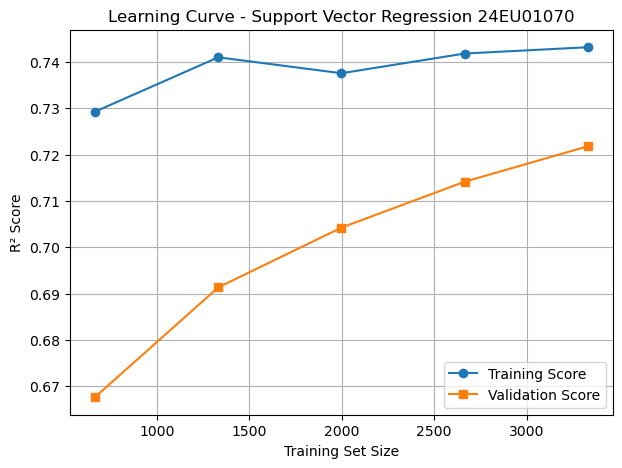

In [40]:
X_train_svr = X_train_scaled[:5000]
y_train_svr = y_train.iloc[:5000]

svr_model = SVR(
    kernel='rbf',
    C=1.0,
    epsilon=0.1
)

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=svr_model,
    X=X_train_svr,
    y=y_train_svr,
    train_sizes=np.linspace(0.2,1.0,5),
    cv=3,
    scoring='r2',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
validation_mean = np.mean(validation_scores, axis=1)

plt.figure(figsize=(7,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Score'
)

plt.plot(
    train_sizes,
    validation_mean,
    marker='s',
    label='Validation Score'
)

plt.title("Learning Curve - Support Vector Regression 24EU01070")

plt.xlabel("Training Set Size")
plt.ylabel("R² Score")

plt.grid(True)
plt.legend()

plt.show()